# **PERSIAPAN DATA**

In [ ]:
# Library utama
import pandas as pd
import numpy as np

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model
from sklearn.ensemble import RandomForestClassifier

# Evaluasi
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

*   panda as pd: untuk manipulasi dan analisis data, terutama untuk bekerja dengan objek DataFrame
*   numpy as np: untuk operasi numerik, khususnya untuk array dan fungsi matematika
*   matplotlib.pyplot as plt: untuk membuat visualisasi statis, animasi, dan interaktif
*   seaborn as sns: untuk menggambar grafik statistik yang menarik
*   sklearn.preprocessing.StandardScaler:untuk menskalakan fitur (menstandardisasi dengan menghilangkan rata-rata dan menskalakan ke varians unit)
*   sklearn.ensemble.RandomForestClassifier: mengimpor algoritma RandomForestClassifier, metode pembelajaran ansambel untuk klasifikasi yang beroperasi.
*   sklearn.model_selection.train_test_split: untuk membagi array atau matriks menjadi subset pelatihan dan pengujian secara acak.
* sklearn.metrics.accuracy_score: untuk menghitung skor akurasi klasifikasi.
* sklearn.metrics.confusion_matrix: untuk menghitung matriks konfusi untuk mengevaluasi akurasi klasifikasi.
* sklearn.metrics.classification_report: untuk membangun laporan teks yang menunjukkan metrik klasifikasi utama (presisi, recall, F1-score) per kelas.









# **LOAD DATA**

In [ ]:
# Upload file
from google.colab import files
uploaded = files.upload()

# Load dataset
train = pd.read_csv('data_training.csv')
test = pd.read_csv('data_testing.csv')

Saving data_training.csv to data_training.csv
Saving data_testing.csv to data_testing.csv


kode ini berfungsi untuk menyiapkan data yang diperlukan untuk analisis atau pembangunan model dengan mengunggahnya dari sumber eksternal dan memuatnya ke dalam struktur DataFrame yang dapat diolah oleh Python

# **EKSPLORASI DATA**

In [ ]:
# Lihat data
train.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
0,7.3,0.740,0.08,1.7,0.094,10.0,45.0,0.99576,3.24,0.50,9.8,5,1366
1,8.1,0.575,0.22,2.1,0.077,12.0,65.0,0.99670,3.29,0.51,9.2,5,103
2,10.1,0.430,0.40,2.6,0.092,13.0,52.0,0.99834,3.22,0.64,10.0,7,942
3,12.9,0.500,0.55,2.8,0.072,7.0,24.0,1.00012,3.09,0.68,10.9,6,811
4,8.4,0.360,0.32,2.2,0.081,32.0,79.0,0.99640,3.30,0.72,11.0,6,918


Perintah train.head() digunakan untuk menampilkan beberapa baris pertama dari dataset train menggunakan pandas. Secara default, fungsi ini akan menampilkan 5 baris teratas dari DataFrame

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 857 entries, 0 to 856
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         857 non-null    float64
 1   volatile acidity      857 non-null    float64
 2   citric acid           857 non-null    float64
 3   residual sugar        857 non-null    float64
 4   chlorides             857 non-null    float64
 5   free sulfur dioxide   857 non-null    float64
 6   total sulfur dioxide  857 non-null    float64
 7   density               857 non-null    float64
 8   pH                    857 non-null    float64
 9   sulphates             857 non-null    float64
 10  alcohol               857 non-null    float64
 11  quality               857 non-null    int64  
 12  Id                    857 non-null    int64  
dtypes: float64(11), int64(2)
memory usage: 87.2 KB


Perintah train.info() digunakan untuk menampilkan ringkasan informasi dari dataset train menggunakan pandas. Output yang dihasilkan mencakup jumlah baris dan kolom dalam dataset, nama-nama variabel, jumlah data yang tidak kosong (non-null) pada setiap kolom, serta tipe data masing-masing variabel seperti float64 atau int64.

Dari output tersebut terlihat bahwa data memiliki 857 baris (entries) dengan indeks dari 0 hingga 856, serta terdiri dari 13 kolom variabel. Seluruh kolom memiliki jumlah data lengkap sebanyak 857 non-null, yang menunjukkan bahwa tidak terdapat missing value dalam dataset sehingga data sudah bersih dan siap digunakan untuk analisis lebih lanjut. Tipe data yang digunakan didominasi oleh float64 pada 11 kolom, yang menandakan bahwa sebagian besar variabel berupa data numerik kontinu seperti tingkat keasaman, kadar alkohol, dan pH, sedangkan 2 kolom lainnya yaitu quality dan Id bertipe int64 yang menunjukkan data numerik diskrit. Secara keseluruhan, dataset ini sudah dalam kondisi baik untuk langsung digunakan dalam analisis data atau pemodelan, dengan kolom quality berpotensi sebagai variabel target dan kolom Id sebagai penanda unik yang biasanya tidak digunakan dalam proses pemodelan.

In [ ]:
train.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,Id
count,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000,857.000000
mean,8.261960,0.529393,0.267351,2.506184,0.086830,15.782964,45.978413,0.996692,3.313092,0.656709,10.430338,5.653442,813.749125
std,1.701992,0.179162,0.195144,1.293512,0.048721,10.300402,31.692113,0.001901,0.152079,0.167364,1.066971,0.821777,463.807063
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.390000,8.400000,3.000000,0.000000
25%,7.100000,0.395000,0.090000,1.900000,0.070000,7.000000,21.000000,0.995520,3.210000,0.550000,9.500000,5.000000,413.000000
50%,7.900000,0.520000,0.250000,2.200000,0.079000,14.000000,38.000000,0.996680,3.310000,0.620000,10.200000,6.000000,814.000000
75%,9.100000,0.640000,0.420000,2.600000,0.090000,21.000000,63.000000,0.997800,3.400000,0.730000,11.100000,6.000000,1214.000000
max,15.600000,1.580000,1.000000,15.500000,0.611000,68.000000,278.000000,1.003200,4.010000,2.000000,14.000000,8.000000,1597.000000


Perintah train.describe() digunakan untuk menampilkan ringkasan statistik deskriptif dari dataset train menggunakan pandas. Output yang dihasilkan mencakup ukuran pemusatan dan penyebaran data untuk setiap kolom numerik, seperti nilai rata-rata (mean), standar deviasi (std), nilai minimum (min), kuartil pertama (25%), median (50%), kuartil ketiga (75%), serta nilai maksimum (max). Informasi ini membantu dalam memahami distribusi data, mendeteksi adanya outlier, serta melihat rentang nilai dari setiap variabel.

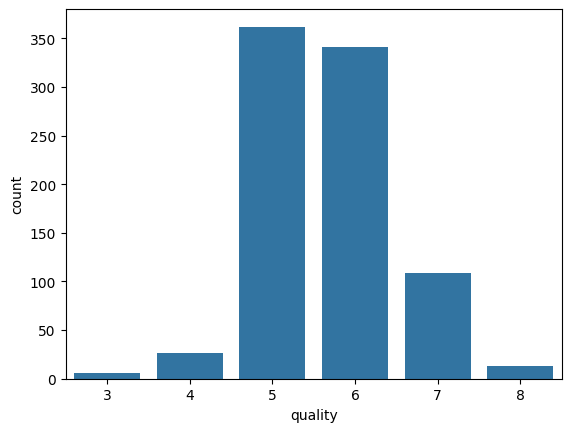

In [ ]:
# Cek distribusi target
sns.countplot(x='quality', data=train)
plt.show()

Plot ini secara visual menunjukan bagaimana kualitas anggur tersebar dalam dataset. Nilai quality seperti 5  dan 6 memiliki batang paling tinggi yang menunjukan bahwa sebagian besar anggur dikategorikan memiliki kualitas 5 atau 6. Untuk nilai 3, 4, 7, 8 memiliki batang yang jauh lebih pendek, bahkan hampir tidak terlihat untuk beberapa kelas, ini menunjukan bahwa sampel untuk kualitas ini sangat dikit.

# **CEK MISSING VALUE**

In [ ]:
train.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


Perintah train.isnull().sum() digunakan untuk mengecek jumlah missing value pada setiap kolom dalam dataset train menggunakan pandas. Fungsi isnull() akan mengidentifikasi nilai yang kosong (NaN) pada setiap elemen data, kemudian sum() akan menjumlahkan jumlah nilai kosong tersebut di setiap kolom.

Setiap baris menunjukkan nama kolom dan angka 0 di sebelahnya.Ini berarti setiap kolom di DataFrame train memiliki 0 nilai yang hilang (null). Dengan kata lain, seluruh dataset train lengkap dan tidak memiliki missing values.

## **PEMISAHAN FITUR & TARGET**

In [ ]:
X = train.drop(['quality', 'Id'], axis=1)
y = train['quality']

Pada baris X = train.drop(['quality', 'Id'], axis=1), dilakukan penghapusan kolom quality dan Id dari DataFrame train, sehingga X hanya berisi variabel-variabel prediktor yang akan digunakan sebagai input model. Kolom quality dihapus karena merupakan variabel target yang ingin diprediksi, sedangkan Id dihapus karena hanya berfungsi sebagai penanda unik data dan tidak memiliki pengaruh terhadap hasil prediksi. Selanjutnya, pada baris y = train['quality'], kolom quality diambil secara terpisah dan disimpan sebagai variabel target (y). Dengan demikian, dataset telah dipisahkan menjadi fitur (X) dan label (y), yang merupakan langkah penting sebelum melakukan proses pelatihan model machine learning.

# **SPLIT DATA TRAINING & VALIDASI**

In [ ]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

Variabel X yang berisi fitur dan y yang berisi target (quality) akan dipecah menjadi empat bagian, yaitu X_train dan y_train sebagai data latih, serta X_val dan y_val sebagai data validasi. Parameter test_size=0.2 menunjukkan bahwa 20% dari total data akan digunakan sebagai data validasi, sedangkan 80% sisanya digunakan untuk melatih model. Sementara itu, random_state=42 berfungsi untuk memastikan bahwa pembagian data dilakukan secara acak namun tetap konsisten setiap kali kode dijalankan, sehingga hasilnya dapat direproduksi.

# **FEATURE SCALING**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

Pada baris scaler = StandardScaler(), dibuat sebuah objek scaler yang berfungsi untuk mengubah skala data sehingga setiap fitur memiliki rata-rata (mean) sebesar 0 dan standar deviasi sebesar 1. Selanjutnya, scaler.fit_transform(X_train) digunakan pada data latih untuk menghitung nilai mean dan standar deviasi dari masing-masing fitur, kemudian langsung mentransformasikan data tersebut ke dalam skala standar. Sementara itu, pada X_val = scaler.transform(X_val), data validasi hanya ditransformasikan menggunakan parameter (mean dan standar deviasi) yang sudah dipelajari dari data latih, tanpa dihitung ulang. Hal ini penting untuk menghindari kebocoran informasi (data leakage) dari data validasi ke data latih. Proses standarisasi ini sangat berpengaruh terutama pada algoritma machine learning yang sensitif terhadap skala data agar performa model menjadi lebih optimal dan stabil.

# **PEMBUATAN MODEL**

In [ ]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

Pada baris model = RandomForestClassifier(n_estimators=100, random_state=42), dibuat sebuah model Random Forest dengan parameter n_estimators=100 yang berarti model akan membangun 100 pohon keputusan (decision trees) sebagai bagian dari ensemble, serta random_state=42 untuk memastikan hasil yang konsisten setiap kali dijalankan. Selanjutnya, pada model.fit(X_train, y_train), model dilatih menggunakan data latih (X_train sebagai fitur dan y_train sebagai target), sehingga model dapat mempelajari pola hubungan antara variabel input dan kualitas wine.

Output yang muncul yaitu RandomForestClassifier(random_state=42) menandakan bahwa model telah berhasil dibuat dan dilatih tanpa error. Meskipun parameter n_estimators=100 tidak ditampilkan dalam output tersebut, model tetap menggunakan nilai tersebut.

# **EVALUASI MODEL**

Accuracy: 0.5813953488372093


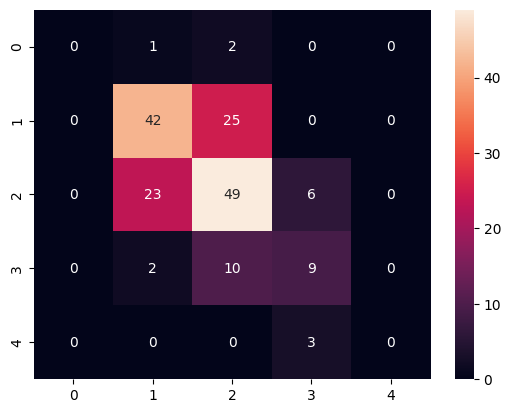

              precision    recall  f1-score   support

           4       0.00      0.00      0.00         3
           5       0.62      0.63      0.62        67
           6       0.57      0.63      0.60        78
           7       0.50      0.43      0.46        21
           8       0.00      0.00      0.00         3

    accuracy                           0.58       172
   macro avg       0.34      0.34      0.34       172
weighted avg       0.56      0.58      0.57       172



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
y_pred = model.predict(X_val)

# Akurasi
print("Accuracy:", accuracy_score(y_val, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_val, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.show()

# Classification Report
print(classification_report(y_val, y_pred))

Berdasarkan hasil evaluasi model menggunakan **scikit-learn**, diperoleh nilai akurasi sebesar sekitar 0,58 yang menunjukkan bahwa model Random Forest mampu memprediksi dengan benar sekitar 58% dari total data validasi. Nilai ini mengindikasikan bahwa performa model masih berada pada kategori sedang dan belum optimal. Dari confusion matrix terlihat bahwa prediksi yang benar paling banyak terjadi pada kelas kualitas 5 dan 6, yang merupakan kelas dengan jumlah data terbesar, ditunjukkan oleh nilai diagonal yang relatif tinggi. Namun, masih terdapat kesalahan prediksi yang cukup signifikan terutama antar kelas yang berdekatan seperti kualitas 5, 6, dan 7, sehingga menunjukkan bahwa model mengalami kesulitan dalam membedakan kelas dengan karakteristik yang mirip. Selain itu, pada kelas kualitas 4 dan 8, model tidak mampu melakukan prediksi dengan baik yang ditunjukkan oleh nilai precision, recall, dan f1-score yang bernilai nol. Hal ini disebabkan oleh jumlah data pada kelas tersebut yang sangat sedikit (data imbalance), sehingga model kurang mampu mempelajari pola dari kelas minoritas. Nilai macro average yang rendah semakin menegaskan bahwa performa model tidak merata di semua kelas, sedangkan weighted average yang lebih tinggi menunjukkan bahwa model cenderung lebih baik pada kelas mayoritas. Secara keseluruhan, model sudah cukup baik dalam mengenali pola umum, tetapi masih memerlukan peningkatan, terutama dalam menangani ketidakseimbangan data dan meningkatkan kemampuan klasifikasi pada kelas minoritas.


# **TRAIN ULANG MODEL FULL DATA**

In [ ]:
# Scaling ulang full data
X_scaled = scaler.fit_transform(X)

# Train full model
model.fit(X_scaled, y)

RandomForestClassifier(random_state=42)

Pada tahap ini dilakukan proses pelatihan ulang model menggunakan seluruh data yang tersedia serta persiapan data testing sebelum dilakukan prediksi. Pertama, dilakukan standarisasi ulang terhadap seluruh fitur pada dataset menggunakan scaler.fit_transform(X), yang berarti scaler menghitung kembali nilai rata-rata dan standar deviasi dari seluruh data, kemudian mengubahnya ke dalam skala yang seragam. Setelah itu, model Random Forest dari scikit-learn dilatih kembali menggunakan data yang sudah discaling secara keseluruhan (X_scaled dan y). Proses ini bertujuan agar model memanfaatkan seluruh informasi yang tersedia sehingga diharapkan menghasilkan performa yang lebih optimal dibandingkan saat hanya menggunakan data training sebelumnya.

# **PREPROCESS DATA TESTING**

In [ ]:
test_id = test['Id']  # simpan id

X_test = test.drop('Id', axis=1)

# scaling
X_test = scaler.transform(X_test)

Pada tahap preprocessing data testing, kolom Id terlebih dahulu dipisahkan dan disimpan ke dalam variabel test_id karena berfungsi sebagai identitas data dan tidak digunakan dalam proses prediksi. Kemudian, kolom Id dihapus dari dataset testing untuk menyisakan hanya fitur yang relevan. Setelah itu, dilakukan proses standarisasi pada data testing menggunakan scaler.transform(X_test), di mana parameter scaling yang digunakan berasal dari data training sebelumnya. Hal ini penting untuk menjaga konsistensi skala antara data training dan data testing serta menghindari kebocoran data (data leakage). Dengan demikian, data testing telah siap digunakan untuk proses prediksi menggunakan model yang telah dilatih.

# **PREDIKSI**

In [ ]:
test_pred = model.predict(X_test)

Baris kode test_pred = model.predict(X_test) digunakan untuk melakukan proses prediksi terhadap data testing menggunakan model yang telah dilatih sebelumnya. Dalam hal ini, model Random Forest dari scikit-learn menerima input berupa X_test, yaitu data fitur yang sudah melalui tahap preprocessing (termasuk penghapusan kolom Id dan proses standarisasi). Kemudian, model akan menghasilkan output berupa prediksi kelas untuk setiap baris data pada dataset testing, yang disimpan dalam variabel test_pred.
Hasil test_pred ini berisi nilai prediksi kualitas (misalnya 4, 5, 6, 7, atau 8) sesuai dengan pola yang telah dipelajari model selama proses training.

# **SIMPAN CSV**

In [ ]:
output = pd.DataFrame({
    'Id': test_id,
    'quality': test_pred})

output.to_csv('hasilprediksi_002.csv', index=False)

Kode tersebut digunakan untuk menyusun hasil prediksi ke dalam bentuk tabel dan menyimpannya sebagai file CSV menggunakan pandas. Pada bagian pd.DataFrame({...}), dibuat sebuah DataFrame baru yang berisi dua kolom, yaitu Id yang diambil dari test_id sebagai identitas setiap data, serta quality yang berisi hasil prediksi model (test_pred). Penggabungan ini penting agar setiap hasil prediksi tetap dapat dilacak ke data aslinya. Selanjutnya, perintah output.to_csv('hasilprediksi_002.csv', index=False) digunakan untuk menyimpan DataFrame tersebut ke dalam file CSV dengan nama hasilprediksi_002.csv.

# **HASIL PREDIKSI**

In [ ]:
prediksi = pd.read_csv('hasilprediksi_002.csv')
prediksi

,Id,quality
0,222,5
1,1514,6
2,417,5
3,754,5
4,516,5
...,...,...
281,1147,6
282,296,5
283,170,5
284,1439,5


Berdasarkan keseluruhan proses analisis yang telah dilakukan, model klasifikasi berhasil dibangun untuk memprediksi kualitas anggur menggunakan algoritma Random Forest.

Tahap awal dimulai dengan eksplorasi data (Exploratory Data Analysis) yang menunjukkan bahwa distribusi kualitas anggur cenderung tidak seimbang, di mana beberapa kelas memiliki jumlah observasi yang lebih dominan dibandingkan kelas lainnya. Selain itu, hasil analisis korelasi menunjukkan bahwa terdapat beberapa fitur yang memiliki hubungan cukup kuat dengan variabel target (quality), seperti alcohol yang berkorelasi positif dan volatile acidity yang berkorelasi negatif.

Pada tahap preprocessing, dilakukan pengecekan terhadap missing values dan diperoleh bahwa dataset tidak memiliki nilai yang hilang, sehingga tidak diperlukan proses imputasi. Selanjutnya, dilakukan normalisasi fitur menggunakan StandardScaler untuk memastikan bahwa setiap variabel berada pada skala yang sebanding, sehingga dapat meningkatkan kinerja model.

Model Random Forest kemudian dilatih menggunakan data training dan dievaluasi menggunakan data validasi. Hasil evaluasi menunjukkan bahwa model memiliki performa yang cukup baik, yang ditunjukkan oleh nilai akurasi serta confusion matrix yang didominasi oleh nilai pada diagonal utama. Hal ini mengindikasikan bahwa model mampu mengklasifikasikan sebagian besar data dengan benar, meskipun masih terdapat beberapa kesalahan prediksi terutama pada kelas yang memiliki karakteristik yang mirip.

Selain itu, analisis feature importance menunjukkan bahwa tidak semua fitur memiliki kontribusi yang sama dalam proses prediksi. Beberapa fitur memiliki pengaruh yang lebih besar dalam menentukan kualitas anggur, yang berarti model lebih mengandalkan fitur-fitur tersebut dalam pengambilan keputusan.

Pada tahap akhir, model yang telah dilatih digunakan untuk memprediksi kualitas anggur pada data testing. Hasil prediksi kemudian disimpan dalam format file CSV sesuai dengan ketentuan, yaitu hanya terdiri dari dua kolom, Id dan quality.

Secara keseluruhan, model yang dibangun telah mampu menangkap pola hubungan antara fitur kimiawi dan kualitas anggur dengan cukup baik. Namun demikian, performa model masih dapat ditingkatkan, misalnya melalui tuning hyperparameter atau penggunaan metode klasifikasi lain untuk memperoleh hasil prediksi yang lebih optimal.